# EViT Token Fusion Testing & Visualization (ImageNet-100)

This notebook tests the EViT (Efficient Vision Transformer) token fusion functionality and provides visualizations of:
- Which patches are kept vs. fused at each reduction layer
- Token fusion behavior (pruned tokens are merged into a single extra token)
- Token reduction statistics
- Performance vs. accuracy trade-offs
- Comparison between EViT and baseline models

In [1]:
# GitHub token-based setup removed.
# If running in a fresh Colab runtime, uncomment these lines:
!git clone https://github.com/Chalhotra/ViT-Token-Economy.git
%cd ViT-Token-Economy

Cloning into 'ViT-Token-Economy'...
remote: Enumerating objects: 376, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (95/95), done.
Receiving objects: 100% (376/376), 1.19 MiB | 14.19 MiB/s, done.
remote: Total 376 (delta 96), reused 99 (delta 59), pack-reused 221 (from 1)
Resolving deltas: 100% (219/219), done.
/content/ViT-Token-Economy


In [2]:
!git checkout prog_test

Branch 'prog_test' set up to track remote branch 'prog_test' from 'origin'.
Switched to a new branch 'prog_test'


In [3]:
!pip -q install -r requirements.txt
!pip -q install -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for vit-deit-baselines (pyproject.toml) ... done


In [4]:
# Import core modules
from src.imagenet_mapping import build_imagenet100_to_1k_map
from src.models import ModelConfig, create_model, shrink_imagenet1k_head_to_imagenet100
from src.data import DataConfig, load_imagenet100_split, build_transform_for_model, apply_timm_preprocess, build_loader
from src.eval import evaluate_accuracy_latency_throughput, compute_gflops
from src.utils import get_device, num_params
from src.test_models.evit import EVITConfig, apply_evit_pruning, BlockEViTAdapter, collect_evit_viz
import torch

# Import visualization libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from typing import List, Dict
import pandas as pd

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
device = get_device()
maps = build_imagenet100_to_1k_map()
print(f"Using device: {device}")

Using device: cuda


## Utility Functions for EViT Visualization

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared palette – one colour per model (cycles if > 8 models) ─────────────
_MODEL_COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B3", "#937860", "#DA8BC3", "#8C8C8C",
]


def _get_model_color(model_id: str, model_list: list) -> str:
    idx = model_list.index(model_id) % len(_MODEL_COLORS)
    return _MODEL_COLORS[idx]


def _style_bar_ax(ax, x, xlabels, ylabel, panel_title):
    ax.set_title(panel_title, fontsize=16, pad=16)
    ax.set_ylabel(ylabel, fontsize=13, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=10)
    ax.tick_params(axis="x", pad=8)
    ax.tick_params(axis="y", pad=6)
    ax.grid(True, axis="y", alpha=0.30)


def _scatter_single(ax, df, x, xlabels, fig):
    """Efficiency scatter – single model, viridis colour ramp by config index."""
    n = len(df)
    sc = ax.scatter(
        df["gflops"], df["acc1"],
        s=150, alpha=0.85, c=np.arange(n), cmap="viridis",
        edgecolors="black", linewidths=0.4,
    )
    _style_scatter_ax(ax)
    for i, (_, row) in enumerate(df.iterrows()):
        label = xlabels[i] if i < len(xlabels) else str(row.get("config_name", i))
        _annotate(ax, row["gflops"], row["acc1"], label, i)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
    cbar.set_label("Configuration Index", fontsize=11, labelpad=8)


def _scatter_multi(ax, df, models, fig):
    """Efficiency scatter – multi-model, one colour per model + legend."""
    for model in models:
        sub   = df[df["model_id"] == model]
        color = _get_model_color(model, models)
        ax.scatter(
            sub["gflops"], sub["acc1"],
            s=150, alpha=0.85, color=color,
            edgecolors="black", linewidths=0.4, label=model, zorder=3,
        )
        for i, (_, row) in enumerate(sub.reset_index(drop=True).iterrows()):
            # Compact annotation: strip verbose prefixes
            label = (
                row["config_name"]
                .replace("keep_rate=", "kr=")
                .replace("EViT ", "")
                .replace("ToMe ", "")
                .strip()
            )
            _annotate(ax, row["gflops"], row["acc1"], label, i)

    _style_scatter_ax(ax)
    ax.legend(fontsize=10, loc="lower right", framealpha=0.85, edgecolor="none")


def _style_scatter_ax(ax):
    ax.set_title("Efficiency: Accuracy vs GFLOPs", fontsize=16, pad=16)
    ax.set_xlabel("GFLOPs", fontsize=13, labelpad=10)
    ax.set_ylabel("Top-1 Accuracy (%)", fontsize=13, labelpad=10)
    ax.tick_params(axis="both", pad=6)
    ax.grid(True, alpha=0.30)


def _annotate(ax, gx, gy, label, i):
    xoff = 8 if i % 2 == 0 else -8
    yoff = 8 if i % 3 else -10
    ax.annotate(
        label,
        (gx, gy),
        xytext=(xoff, yoff),
        textcoords="offset points",
        fontsize=9,
        ha="left" if xoff > 0 else "right",
        va="bottom" if yoff > 0 else "top",
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                  alpha=0.72, edgecolor="none"),
    )


In [37]:
def _extract_evit_group_key(df: pd.DataFrame) -> pd.Series:
    """
    Derive a sort/group key from config_name, handling three formats:

      1. "… keep_rate=0.70 …"     → "kr=0.70"
      2. "… keep=[0.70,0.70,…]"   → "keep=[0.70,0.70,…]"  (full bracket string)
      3. anything else             → config_name with model_id prefix stripped
    """
    keys = []
    for _, row in df.iterrows():
        name  = str(row["config_name"])
        model = str(row.get("model_id", ""))

        # Format 1: keep_rate=0.XX
        m1 = pd.Series([name]).str.extract(r"keep_rate=(\d+\.\d+)")[0][0]
        if pd.notna(m1):
            keys.append(f"kr={float(m1):.2f}")
            continue

        # Format 2: keep=[...]
        m2 = pd.Series([name]).str.extract(r"(keep=\[[^\]]+\])")[0][0]
        if pd.notna(m2):
            keys.append(m2)
            continue

        # Format 3: strip model_id prefix
        stripped = name.replace(model, "").strip(" _-|")
        keys.append(stripped if stripped else name)

    return pd.Series(keys, index=df.index)


def _shorten_evit_labels(group_keys: list) -> list:
    """
    Produce compact x-tick labels from EViT group keys.

    "kr=0.70"                      → "kr=0.70"
    "keep=[0.70,0.70,0.70]"        → "[.70×3]"
    "keep=[0.90,0.70,0.50]"        → "[.90,.70,.50]"
    anything else                  → truncated to 14 chars
    """
    labels = []
    for key in group_keys:
        if key.startswith("kr="):
            labels.append(key)
            continue

        inner_match = pd.Series([key]).str.extract(r"keep=\[([^\]]+)\]")[0][0]
        if pd.notna(inner_match):
            vals       = [v.strip() for v in inner_match.split(",")]
            short_vals = [v.lstrip("0") if v.startswith("0.") else v for v in vals]
            unique_vals = list(dict.fromkeys(short_vals))
            if len(unique_vals) == 1:
                labels.append(f"[{unique_vals[0]}×{len(short_vals)}]")
            else:
                labels.append("[" + ",".join(short_vals) + "]")
            continue

        labels.append(key[:14] + "…" if len(key) > 14 else key)

    return labels



In [38]:
def extract_evit_fusion_info(model, x):
    """
    Extract token fusion information from EViT blocks.
    Returns list of (layer_idx, kept_indices, complement_indices) and token counts.
    """
    fusion_info = []
    token_counts = []

    # Get initial token count
    B, N, C = x.shape
    num_special = 2 if hasattr(model, 'dist_token') and model.dist_token is not None else 1
    token_counts.append(N - num_special)  # exclude special tokens

    # Forward through blocks and collect fusion info
    for i, block in enumerate(model.blocks):
        with torch.no_grad():
            x = block(x)

        # Check if this is an EViT block
        if isinstance(block, BlockEViTAdapter):
            idx = block.last_idx
            compl = block.last_compl

            if idx is not None:
                # idx contains kept indices plus sentinel (-1) for fused token
                kept_tokens = idx[:, :-1]  # Remove the -1 sentinel
                fusion_info.append((i, kept_tokens.cpu(), compl.cpu() if compl is not None else None))
                # Token count after fusion: kept + 1 (fused token)
                token_counts.append(kept_tokens.shape[1] + 1)
            else:
                token_counts.append(token_counts[-1])
        else:
            token_counts.append(token_counts[-1])

    return fusion_info, token_counts


def visualize_evit_fusion(image, patch_size, fusion_info, token_counts, model_name):
    """
    Visualize which patches are kept vs. fused in EViT.

    Args:
        image: Original PIL image or tensor
        patch_size: Size of patches (e.g., 16)
        fusion_info: List of (layer_idx, kept_indices_tensor, fused_indices_tensor)
        token_counts: List of token counts at each layer
        model_name: Name for the plot title
    """
    # Convert image to numpy if needed
    if isinstance(image, torch.Tensor):
        img_np = image.permute(1, 2, 0).cpu().numpy()
    else:
        img_np = np.array(image)

    # Normalize if needed
    if img_np.max() > 1.0:
        img_np = img_np / 255.0

    h, w = img_np.shape[:2]
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size
    total_patches = n_patches_h * n_patches_w

    # Create visualization
    n_fusion_layers = len(fusion_info)
    fig, axes = plt.subplots(1, n_fusion_layers + 1, figsize=(5 * (n_fusion_layers + 1), 5))
    if n_fusion_layers == 0:
        axes = [axes]

    # Show original image
    axes[0].imshow(img_np)
    axes[0].set_title(f'Original Image\n{total_patches} patches')
    axes[0].axis('off')

    # Show fusion at each layer
    for idx, (layer_idx, kept_indices, fused_indices) in enumerate(fusion_info):
        ax = axes[idx + 1]

        # Create masks for kept and fused patches
        kept_mask = np.zeros((n_patches_h, n_patches_w))
        fused_mask = np.zeros((n_patches_h, n_patches_w))

        kept_idx_np = kept_indices[0].numpy()  # Take first batch item

        # Mark kept patches
        for ki in kept_idx_np:
            pi = ki % n_patches_h
            pj = ki // n_patches_h
            if pi < n_patches_h and pj < n_patches_w:
                kept_mask[pi, pj] = 1

        # Mark fused patches
        if fused_indices is not None:
            fused_idx_np = fused_indices[0].numpy()
            for fi in fused_idx_np:
                pi = fi % n_patches_h
                pj = fi // n_patches_h
                if pi < n_patches_h and pj < n_patches_w:
                    fused_mask[pi, pj] = 1

        # Create overlay
        overlay = img_np.copy()
        for i in range(n_patches_h):
            for j in range(n_patches_w):
                y_start, y_end = i * patch_size, (i + 1) * patch_size
                x_start, x_end = j * patch_size, (j + 1) * patch_size

                if fused_mask[i, j] == 1:  # Fused patch (orange tint)
                    overlay[y_start:y_end, x_start:x_end, 0] = np.clip(
                        overlay[y_start:y_end, x_start:x_end, 0] * 0.5 + 0.5, 0, 1
                    )
                    overlay[y_start:y_end, x_start:x_end, 1] = overlay[y_start:y_end, x_start:x_end, 1] * 0.5
                    overlay[y_start:y_end, x_start:x_end, 2] = overlay[y_start:y_end, x_start:x_end, 2] * 0.3

        kept_count = int(kept_mask.sum())
        fused_count = int(fused_mask.sum())
        keep_rate = kept_count / total_patches

        ax.imshow(overlay)
        ax.set_title(
            f'After Layer {layer_idx}\n'
            f'{kept_count} kept + 1 fused ({keep_rate:.1%})\n'
            f'Fused {fused_count} patches into 1 token'
        )
        ax.axis('off')

    plt.suptitle(f'{model_name} - EViT Token Fusion Visualization', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_evit_token_timeline(token_counts, reduction_locs, model_name):
    """
    Plot how token count changes through layers with EViT fusion.
    Note: EViT keeps top-K tokens and adds 1 fused token.
    """
    layers = list(range(len(token_counts)))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(layers, token_counts, marker='o', linewidth=2, markersize=8, label='Total tokens')

    # Highlight reduction locations
    for loc in reduction_locs:
        if loc < len(token_counts):
            ax.axvline(x=loc, color='red', linestyle='--', alpha=0.5)
            ax.text(loc, max(token_counts) * 0.95, f'Fusion at {loc}',
                   rotation=90, verticalalignment='top', fontsize=9)

    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Number of Patch Tokens (including fused)', fontsize=12)
    ax.set_title(f'{model_name} - Token Count Through Layers (EViT)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Add percentage annotations
    initial = token_counts[0]
    for i, count in enumerate(token_counts):
        if i in reduction_locs or i == 0 or i == len(token_counts) - 1:
            pct = count / initial * 100
            ax.annotate(f'{count} ({pct:.1f}%)',
                       xy=(i, count),
                       xytext=(0, 10),
                       textcoords='offset points',
                       ha='center',
                       fontsize=9,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))

    plt.tight_layout()
    plt.show()



def compare_evit_configurations_spacious(
    results_list: List[Dict],
    title: str = "EViT Configuration Comparison",
):
    """
    Spacious 2x2 comparison plot for EViT sweep results.

    Supports both single-model and multi-model result lists.
    Each dict should contain at minimum:
        config_name, acc1, gflops, latency_ms
    For multi-model sweeps, also include:
        model_id  (e.g. "deit_tiny", "vit_small")

    Single-model  -> flat coloured bars, labels like "kr=0.70"
    Multi-model   -> grouped bars per keep-rate, one colour per model,
                     automatic legend; scatter points coloured by model
    """
    if not results_list:
        print("No results to plot.")
        return

    df = pd.DataFrame(results_list).copy()
    if df.empty:
        print("No results to plot.")
        return

    if "model_id" not in df.columns:
        df["model_id"] = "model"

    df["_group_key"] = _extract_evit_group_key(df)

    models = sorted(df["model_id"].unique().tolist())
    multi  = len(models) > 1

    plt.close("all")
    fig, axes = plt.subplots(2, 2, figsize=(24, 16), dpi=130, constrained_layout=False)
    fig.subplots_adjust(left=0.06, right=0.985, bottom=0.24, top=0.90,
                        wspace=0.28, hspace=0.42)

    if multi:
        _evit_multi_model(df, models, axes, fig)
    else:
        _evit_single_model(df, axes, fig)

    fig.suptitle(title, fontsize=20, y=0.965)
    plt.show()

    print("\n" + "=" * 80)
    print(f"{title} – Summary Table")
    print("=" * 80)
    print(df.drop(columns=["_group_key"], errors="ignore").to_string(index=False))
    print("=" * 80 + "\n")


def _evit_single_model(df: pd.DataFrame, axes, fig):
    df = df.sort_values(["_group_key", "config_name"], na_position="last")
    n = len(df)
    x = np.arange(n)
    xlabels = _shorten_evit_labels(df["_group_key"].tolist())

    for ax, col, color, ylabel, panel_title in [
        (axes[0, 0], "acc1",       "steelblue",     "Accuracy (%)", "Top-1 Accuracy"),
        (axes[0, 1], "gflops",     "coral",          "GFLOPs",       "Computational Cost"),
        (axes[1, 0], "latency_ms", "mediumseagreen", "Latency (ms)", "Inference Latency"),
    ]:
        ax.bar(x, df[col], color=color, alpha=0.9)
        _style_bar_ax(ax, x, xlabels, ylabel, panel_title)

    _scatter_single(axes[1, 1], df, x, xlabels, fig)


def _evit_multi_model(df: pd.DataFrame, models: list, axes, fig):
    group_keys = sorted(df["_group_key"].unique().tolist())
    xlabels    = _shorten_evit_labels(group_keys)
    n_groups   = len(group_keys)
    n_models   = len(models)
    bar_w      = 0.7 / n_models
    group_x    = np.arange(n_groups)

    for ax, col, ylabel, panel_title in [
        (axes[0, 0], "acc1",       "Accuracy (%)", "Top-1 Accuracy"),
        (axes[0, 1], "gflops",     "GFLOPs",       "Computational Cost"),
        (axes[1, 0], "latency_ms", "Latency (ms)", "Inference Latency"),
    ]:
        for mi, model in enumerate(models):
            sub  = df[df["model_id"] == model]
            vals = [
                sub.loc[sub["_group_key"] == gk, col].values[0]
                if gk in sub["_group_key"].values else np.nan
                for gk in group_keys
            ]
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(group_x + offset, vals, width=bar_w * 0.92,
                   color=_get_model_color(model, models), alpha=0.9, label=model)
        _style_bar_ax(ax, group_x, xlabels, ylabel, panel_title)

    _scatter_multi(axes[1, 1], df, models, fig)

    handles = [
        mpatches.Patch(color=_get_model_color(m, models), label=m)
        for m in models
    ]
    axes[0, 0].legend(handles=handles, fontsize=10, loc="lower right",
                      framealpha=0.85, edgecolor="none")


## Test EViT with Different Configurations

In [8]:
def run_evit_test(
    model_id: str,
    evit_config: EVITConfig,
    config_name: str,
    batch_size: int = 64,
    visualize: bool = True
):
    """
    Run model with specific EViT configuration and optionally visualize.
    """
    print(f"\n{'='*80}")
    print(f"Testing: {config_name}")
    print(f"Model: {model_id}")
    print(f"Reduction locations: {evit_config.reduction_loc}")
    print(f"Keep rates: {evit_config.keep_rate}")
    print(f"{'='*80}\n")

    # Create model
    model = create_model(ModelConfig(model_id=model_id, pretrained=True))
    model = shrink_imagenet1k_head_to_imagenet100(model, maps.new_to_old_map, num_classes=100)

    # Apply EViT pruning
    model = apply_evit_pruning(model, evit_config)
    model = model.to(device).eval()

    # Load data
    ds = load_imagenet100_split(DataConfig(split='validation'))
    transform = build_transform_for_model(model)
    ds_t = apply_timm_preprocess(ds, transform)
    loader = build_loader(ds_t, DataConfig(batch_size=batch_size, split='validation', shuffle=False))

    # Evaluate
    metrics = evaluate_accuracy_latency_throughput(model, loader, device)

    # Compute GFLOPs
    sample = ds_t[0]['pixel_values'].unsqueeze(0).to(device)
    gflops = compute_gflops(model, sample)

    # Visualization
    if visualize and evit_config.enabled:
        # Get a sample image for visualization
        sample_idx = 42  # arbitrary sample
        sample_image = ds[sample_idx]['image']
        sample_tensor = ds_t[sample_idx]['pixel_values'].unsqueeze(0).to(device)

        # Extract fusion information
        with torch.no_grad():
            # Embed patches
            x = model.patch_embed(sample_tensor)
            if hasattr(model, 'cls_token'):
                cls_tokens = model.cls_token.expand(sample_tensor.shape[0], -1, -1)
                x = torch.cat((cls_tokens, x), dim=1)
            if hasattr(model, 'pos_embed'):
                x = x + model.pos_embed
            if hasattr(model, 'pos_drop'):
                x = model.pos_drop(x)

            # Extract fusion info
            fusion_info, token_counts = extract_evit_fusion_info(model, x)

        # Visualize token fusion
        if fusion_info:
            visualize_evit_fusion(
                sample_image,
                16,  # patch size
                fusion_info,
                token_counts,
                f"{model_id} - {config_name}"
            )

            # Plot token timeline
            plot_evit_token_timeline(
                token_counts,
                list(evit_config.reduction_loc),
                f"{model_id} - {config_name}"
            )

    result = {
        'config_name': config_name,
        'model': model_id,
        'params_m': num_params(model) / 1e6,
        'gflops': gflops,
        **metrics
    }

    print(f"\nResults for {config_name}:")
    print(f"  Top-1 Accuracy: {metrics['acc1']:.2f}%")
    print(f"  GFLOPs: {gflops:.3f}")
    print(f"  Latency: {metrics['latency_ms']:.2f} ms")
    print(f"  Throughput: {metrics['throughput']:.1f} samples/sec")

    return result

## Baseline (No Fusion)

In [9]:
# Test baseline without EViT
baseline_config = EVITConfig(enabled=False)
baseline_result = run_evit_test(
    model_id='deit_tiny_patch16_224',
    evit_config=baseline_config,
    config_name='Baseline (No Fusion)',
    visualize=False
)


Testing: Baseline (No Fusion)
Model: deit_tiny_patch16_224
Reduction locations: ()
Keep rates: (1.0,)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

...

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop



Results for Baseline (No Fusion):
  Top-1 Accuracy: 88.42%
  GFLOPs: 1.079
  Latency: 1.35 ms
  Throughput: 740.6 samples/sec


## Sanity Check: Keep Rate = 1.0 (Should Match Baseline)

In [10]:
# Sanity check: keep_rate = 1.0 should yield same accuracy
sanity_config = EVITConfig(
    enabled=True,
    keep_rate=(1.0,),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False
)
sanity_result = run_evit_test(
    model_id='deit_tiny_patch16_224',
    evit_config=sanity_config,
    config_name='Sanity Check (keep=1.0)',
    visualize=True
)


Testing: Sanity Check (keep=1.0)
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (1.0,)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop



Results for Sanity Check (keep=1.0):
  Top-1 Accuracy: 88.42%
  GFLOPs: 1.079
  Latency: 1.32 ms
  Throughput: 760.0 samples/sec


In [11]:
# EViT sweep: deit_tiny_patch16_224, keep_rate=0.25
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.25, 0.25, 0.25),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_tiny_patch16_224 keep=[0.25,0.25,0.25]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_tiny_patch16_224 keep=[0.25,0.25,0.25]
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_tiny_patch16_224 keep=[0.25,0.25,0.25]:
  Top-1 Accuracy: 52.54%
  GFLOPs: 0.432
  Latency: 0.75 ms
  Throughput: 1338.1 samples/sec


In [12]:
# EViT sweep: deit_tiny_patch16_224, keep_rate=0.50
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.5, 0.5, 0.5),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_tiny_patch16_224 keep=[0.50,0.50,0.50]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_tiny_patch16_224 keep=[0.50,0.50,0.50]
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.5, 0.5, 0.5)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_tiny_patch16_224 keep=[0.50,0.50,0.50]:
  Top-1 Accuracy: 80.34%
  GFLOPs: 0.576
  Latency: 0.75 ms
  Throughput: 1330.8 samples/sec


In [13]:
# EViT sweep: deit_tiny_patch16_224, keep_rate=0.70
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.7, 0.7, 0.7),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_tiny_patch16_224 keep=[0.70,0.70,0.70]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_tiny_patch16_224 keep=[0.70,0.70,0.70]
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.7, 0.7, 0.7)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_tiny_patch16_224 keep=[0.70,0.70,0.70]:
  Top-1 Accuracy: 86.42%
  GFLOPs: 0.752
  Latency: 0.98 ms
  Throughput: 1016.4 samples/sec


In [14]:
# EViT sweep: deit_tiny_patch16_224, keep_rate=0.90
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.9, 0.9, 0.9),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_tiny_patch16_224 keep=[0.90,0.90,0.90]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_tiny_patch16_224 keep=[0.90,0.90,0.90]
Model: deit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.9, 0.9, 0.9)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_tiny_patch16_224 keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 88.44%
  GFLOPs: 0.989
  Latency: 1.24 ms
  Throughput: 805.7 samples/sec


In [15]:
# EViT sweep: deit_small_patch16_224, keep_rate=0.25
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.25, 0.25, 0.25),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_small_patch16_224 keep=[0.25,0.25,0.25]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_small_patch16_224 keep=[0.25,0.25,0.25]
Model: deit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)



model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_small_patch16_224 keep=[0.25,0.25,0.25]:
  Top-1 Accuracy: 70.16%
  GFLOPs: 1.634
  Latency: 1.25 ms
  Throughput: 797.8 samples/sec


In [16]:
# EViT sweep: deit_small_patch16_224, keep_rate=0.50
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.5, 0.5, 0.5),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_small_patch16_224 keep=[0.50,0.50,0.50]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_small_patch16_224 keep=[0.50,0.50,0.50]
Model: deit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.5, 0.5, 0.5)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_small_patch16_224 keep=[0.50,0.50,0.50]:
  Top-1 Accuracy: 89.02%
  GFLOPs: 2.203
  Latency: 1.76 ms
  Throughput: 567.3 samples/sec


In [17]:
# EViT sweep: deit_small_patch16_224, keep_rate=0.70
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.7, 0.7, 0.7),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_small_patch16_224 keep=[0.70,0.70,0.70]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_small_patch16_224 keep=[0.70,0.70,0.70]
Model: deit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.7, 0.7, 0.7)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_small_patch16_224 keep=[0.70,0.70,0.70]:
  Top-1 Accuracy: 91.80%
  GFLOPs: 2.892
  Latency: 2.39 ms
  Throughput: 418.3 samples/sec


In [18]:
# EViT sweep: deit_small_patch16_224, keep_rate=0.90
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.9, 0.9, 0.9),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_small_patch16_224 keep=[0.90,0.90,0.90]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_small_patch16_224 keep=[0.90,0.90,0.90]
Model: deit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.9, 0.9, 0.9)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_small_patch16_224 keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 92.46%
  GFLOPs: 3.817
  Latency: 3.26 ms
  Throughput: 307.1 samples/sec


In [19]:
# EViT sweep: deit_base_patch16_224, keep_rate=0.25
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.25, 0.25, 0.25),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_base_patch16_224 keep=[0.25,0.25,0.25]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_base_patch16_224 keep=[0.25,0.25,0.25]
Model: deit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_base_patch16_224 keep=[0.25,0.25,0.25]:
  Top-1 Accuracy: 51.32%
  GFLOPs: 6.349
  Latency: 5.06 ms
  Throughput: 197.7 samples/sec


In [20]:
# EViT sweep: deit_base_patch16_224, keep_rate=0.50
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.5, 0.5, 0.5),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_base_patch16_224 keep=[0.50,0.50,0.50]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_base_patch16_224 keep=[0.50,0.50,0.50]
Model: deit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.5, 0.5, 0.5)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_base_patch16_224 keep=[0.50,0.50,0.50]:
  Top-1 Accuracy: 89.00%
  GFLOPs: 8.608
  Latency: 6.73 ms
  Throughput: 148.6 samples/sec


In [21]:
# EViT sweep: deit_base_patch16_224, keep_rate=0.70
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.7, 0.7, 0.7),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_base_patch16_224 keep=[0.70,0.70,0.70]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_base_patch16_224 keep=[0.70,0.70,0.70]
Model: deit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.7, 0.7, 0.7)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_base_patch16_224 keep=[0.70,0.70,0.70]:
  Top-1 Accuracy: 93.06%
  GFLOPs: 11.336
  Latency: 8.77 ms
  Throughput: 114.0 samples/sec


In [22]:
# EViT sweep: deit_base_patch16_224, keep_rate=0.90
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.9, 0.9, 0.9),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT deit_base_patch16_224 keep=[0.90,0.90,0.90]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='deit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT deit_base_patch16_224 keep=[0.90,0.90,0.90]
Model: deit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.9, 0.9, 0.9)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT deit_base_patch16_224 keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 93.76%
  GFLOPs: 14.985
  Latency: 11.56 ms
  Throughput: 86.5 samples/sec


In [23]:
# EViT sweep: vit_tiny_patch16_224, keep_rate=0.25
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.25, 0.25, 0.25),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_tiny_patch16_224 keep=[0.25,0.25,0.25]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_tiny_patch16_224 keep=[0.25,0.25,0.25]
Model: vit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)



model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_tiny_patch16_224 keep=[0.25,0.25,0.25]:
  Top-1 Accuracy: 44.06%
  GFLOPs: 0.432
  Latency: 0.66 ms
  Throughput: 1514.3 samples/sec


In [24]:
# EViT sweep: vit_tiny_patch16_224, keep_rate=0.50
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.5, 0.5, 0.5),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_tiny_patch16_224 keep=[0.50,0.50,0.50]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_tiny_patch16_224 keep=[0.50,0.50,0.50]
Model: vit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.5, 0.5, 0.5)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_tiny_patch16_224 keep=[0.50,0.50,0.50]:
  Top-1 Accuracy: 79.72%
  GFLOPs: 0.576
  Latency: 0.75 ms
  Throughput: 1328.2 samples/sec


In [25]:
# EViT sweep: vit_tiny_patch16_224, keep_rate=0.70
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.7, 0.7, 0.7),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_tiny_patch16_224 keep=[0.70,0.70,0.70]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_tiny_patch16_224 keep=[0.70,0.70,0.70]
Model: vit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.7, 0.7, 0.7)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_tiny_patch16_224 keep=[0.70,0.70,0.70]:
  Top-1 Accuracy: 86.92%
  GFLOPs: 0.752
  Latency: 1.04 ms
  Throughput: 965.2 samples/sec


In [26]:
# EViT sweep: vit_tiny_patch16_224, keep_rate=0.90
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.9, 0.9, 0.9),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_tiny_patch16_224 keep=[0.90,0.90,0.90]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_tiny_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_tiny_patch16_224 keep=[0.90,0.90,0.90]
Model: vit_tiny_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.9, 0.9, 0.9)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_tiny_patch16_224 keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 89.08%
  GFLOPs: 0.989
  Latency: 1.10 ms
  Throughput: 912.3 samples/sec


In [27]:
# EViT sweep: vit_small_patch16_224, keep_rate=0.25
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.25, 0.25, 0.25),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_small_patch16_224 keep=[0.25,0.25,0.25]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_small_patch16_224 keep=[0.25,0.25,0.25]
Model: vit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)



model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_small_patch16_224 keep=[0.25,0.25,0.25]:
  Top-1 Accuracy: 35.48%
  GFLOPs: 1.634
  Latency: 1.25 ms
  Throughput: 797.1 samples/sec


In [28]:
# EViT sweep: vit_small_patch16_224, keep_rate=0.50
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.5, 0.5, 0.5),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_small_patch16_224 keep=[0.50,0.50,0.50]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_small_patch16_224 keep=[0.50,0.50,0.50]
Model: vit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.5, 0.5, 0.5)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_small_patch16_224 keep=[0.50,0.50,0.50]:
  Top-1 Accuracy: 82.80%
  GFLOPs: 2.203
  Latency: 1.74 ms
  Throughput: 573.5 samples/sec


In [29]:
# EViT sweep: vit_small_patch16_224, keep_rate=0.70
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.7, 0.7, 0.7),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_small_patch16_224 keep=[0.70,0.70,0.70]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_small_patch16_224 keep=[0.70,0.70,0.70]
Model: vit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.7, 0.7, 0.7)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_small_patch16_224 keep=[0.70,0.70,0.70]:
  Top-1 Accuracy: 91.28%
  GFLOPs: 2.892
  Latency: 2.36 ms
  Throughput: 423.4 samples/sec


In [30]:
# EViT sweep: vit_small_patch16_224, keep_rate=0.90
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.9, 0.9, 0.9),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_small_patch16_224 keep=[0.90,0.90,0.90]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_small_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_small_patch16_224 keep=[0.90,0.90,0.90]
Model: vit_small_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.9, 0.9, 0.9)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_small_patch16_224 keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 93.06%
  GFLOPs: 3.817
  Latency: 3.26 ms
  Throughput: 306.7 samples/sec


In [31]:
# EViT sweep: vit_base_patch16_224, keep_rate=0.25
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.25, 0.25, 0.25),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_base_patch16_224 keep=[0.25,0.25,0.25]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_base_patch16_224 keep=[0.25,0.25,0.25]
Model: vit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.25, 0.25, 0.25)



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_base_patch16_224 keep=[0.25,0.25,0.25]:
  Top-1 Accuracy: 61.00%
  GFLOPs: 6.349
  Latency: 5.06 ms
  Throughput: 197.6 samples/sec


In [32]:
# EViT sweep: vit_base_patch16_224, keep_rate=0.50
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.5, 0.5, 0.5),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_base_patch16_224 keep=[0.50,0.50,0.50]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_base_patch16_224 keep=[0.50,0.50,0.50]
Model: vit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.5, 0.5, 0.5)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_base_patch16_224 keep=[0.50,0.50,0.50]:
  Top-1 Accuracy: 92.48%
  GFLOPs: 8.608
  Latency: 6.70 ms
  Throughput: 149.3 samples/sec


In [33]:
# EViT sweep: vit_base_patch16_224, keep_rate=0.70
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.7, 0.7, 0.7),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_base_patch16_224 keep=[0.70,0.70,0.70]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_base_patch16_224 keep=[0.70,0.70,0.70]
Model: vit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.7, 0.7, 0.7)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_base_patch16_224 keep=[0.70,0.70,0.70]:
  Top-1 Accuracy: 95.04%
  GFLOPs: 11.336
  Latency: 8.82 ms
  Throughput: 113.4 samples/sec


In [34]:
# EViT sweep: vit_base_patch16_224, keep_rate=0.90
if 'results' not in globals():
    results = [baseline_result, sanity_result]

cfg = EVITConfig(
    enabled=True,
    keep_rate=(0.9, 0.9, 0.9),
    reduction_loc=(3, 6, 9),
    exponentiate_single_keep_rate=False,
)
name = 'EViT vit_base_patch16_224 keep=[0.90,0.90,0.90]'
results = [x for x in results if x.get('config_name') != name]
out = run_evit_test(
    model_id='vit_base_patch16_224',
    evit_config=cfg,
    config_name=name,
    visualize=False,
)
results.append(out)


Testing: EViT vit_base_patch16_224 keep=[0.90,0.90,0.90]
Model: vit_base_patch16_224
Reduction locations: (3, 6, 9)
Keep rates: (0.9, 0.9, 0.9)



Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop



Results for EViT vit_base_patch16_224 keep=[0.90,0.90,0.90]:
  Top-1 Accuracy: 95.54%
  GFLOPs: 14.985
  Latency: 11.57 ms
  Throughput: 86.4 samples/sec


In [35]:
# Final combined comparison table for explicit keep-rate sweeps across all models
if 'results' not in globals() or not results:
    print('No explicit sweep results found yet. Run the explicit sweep cells first.')
else:
    df_all = pd.DataFrame(results)
    df_explicit = df_all[df_all['config_name'].str.startswith('EViT ')].copy()

    if not df_explicit.empty:
        extracted = df_explicit['config_name'].str.extract(
            r"^EViT\s+(?P<model>\S+)\s+keep=\[(?P<keep>\d+\.\d+),"
        )
        df_explicit['model'] = extracted['model']
        df_explicit['keep_rate'] = pd.to_numeric(extracted['keep'], errors='coerce')
        df_explicit = df_explicit.sort_values(['model', 'keep_rate'])

        cols = [
            c for c in [
                'model', 'keep_rate', 'config_name', 'acc1', 'latency_ms', 'throughput', 'gflops', 'params_m'
            ] if c in df_explicit.columns
        ]
        display(df_explicit[cols].reset_index(drop=True))
    else:
        print('No EViT explicit sweep results found yet. Run the explicit sweep cells first.')

,model,keep_rate,config_name,acc1,latency_ms,throughput,gflops,params_m
0,deit_base_patch16_224,0.25,"EViT deit_base_patch16_224 keep=[0.25,0.25,0.25]",51.32,5.058464,197.688470,6.349069,85.875556
1,deit_base_patch16_224,0.50,"EViT deit_base_patch16_224 keep=[0.50,0.50,0.50]",89.00,6.728473,148.622142,8.608061,85.875556
2,deit_base_patch16_224,0.70,"EViT deit_base_patch16_224 keep=[0.70,0.70,0.70]",93.06,8.770612,114.017130,11.336089,85.875556
3,deit_base_patch16_224,0.90,"EViT deit_base_patch16_224 keep=[0.90,0.90,0.90]",93.76,11.559406,86.509635,14.985036,85.875556
4,deit_small_patch16_224,0.25,"EViT deit_small_patch16_224 keep=[0.25,0.25,0.25]",70.16,1.253400,797.829698,1.633914,21.704164
5,deit_small_patch16_224,0.50,"EViT deit_small_patch16_224 keep=[0.50,0.50,0.50]",89.02,1.762803,567.278404,2.203078,21.704164
6,deit_small_patch16_224,0.70,"EViT deit_small_patch16_224 keep=[0.70,0.70,0.70]",91.80,2.390418,418.336928,2.892333,21.704164
7,deit_small_patch16_224,0.90,"EViT deit_small_patch16_224 keep=[0.90,0.90,0.90]",92.46,3.256205,307.105978,3.816735,21.704164
8,deit_tiny_patch16_224,0.25,"EViT deit_tiny_patch16_224 keep=[0.25,0.25,0.25]",52.54,0.747353,1338.056483,0.431802,5.543716
9,deit_tiny_patch16_224,0.50,"EViT deit_tiny_patch16_224 keep=[0.50,0.50,0.50]",80.34,0.751450,1330.760311,0.576300,5.543716


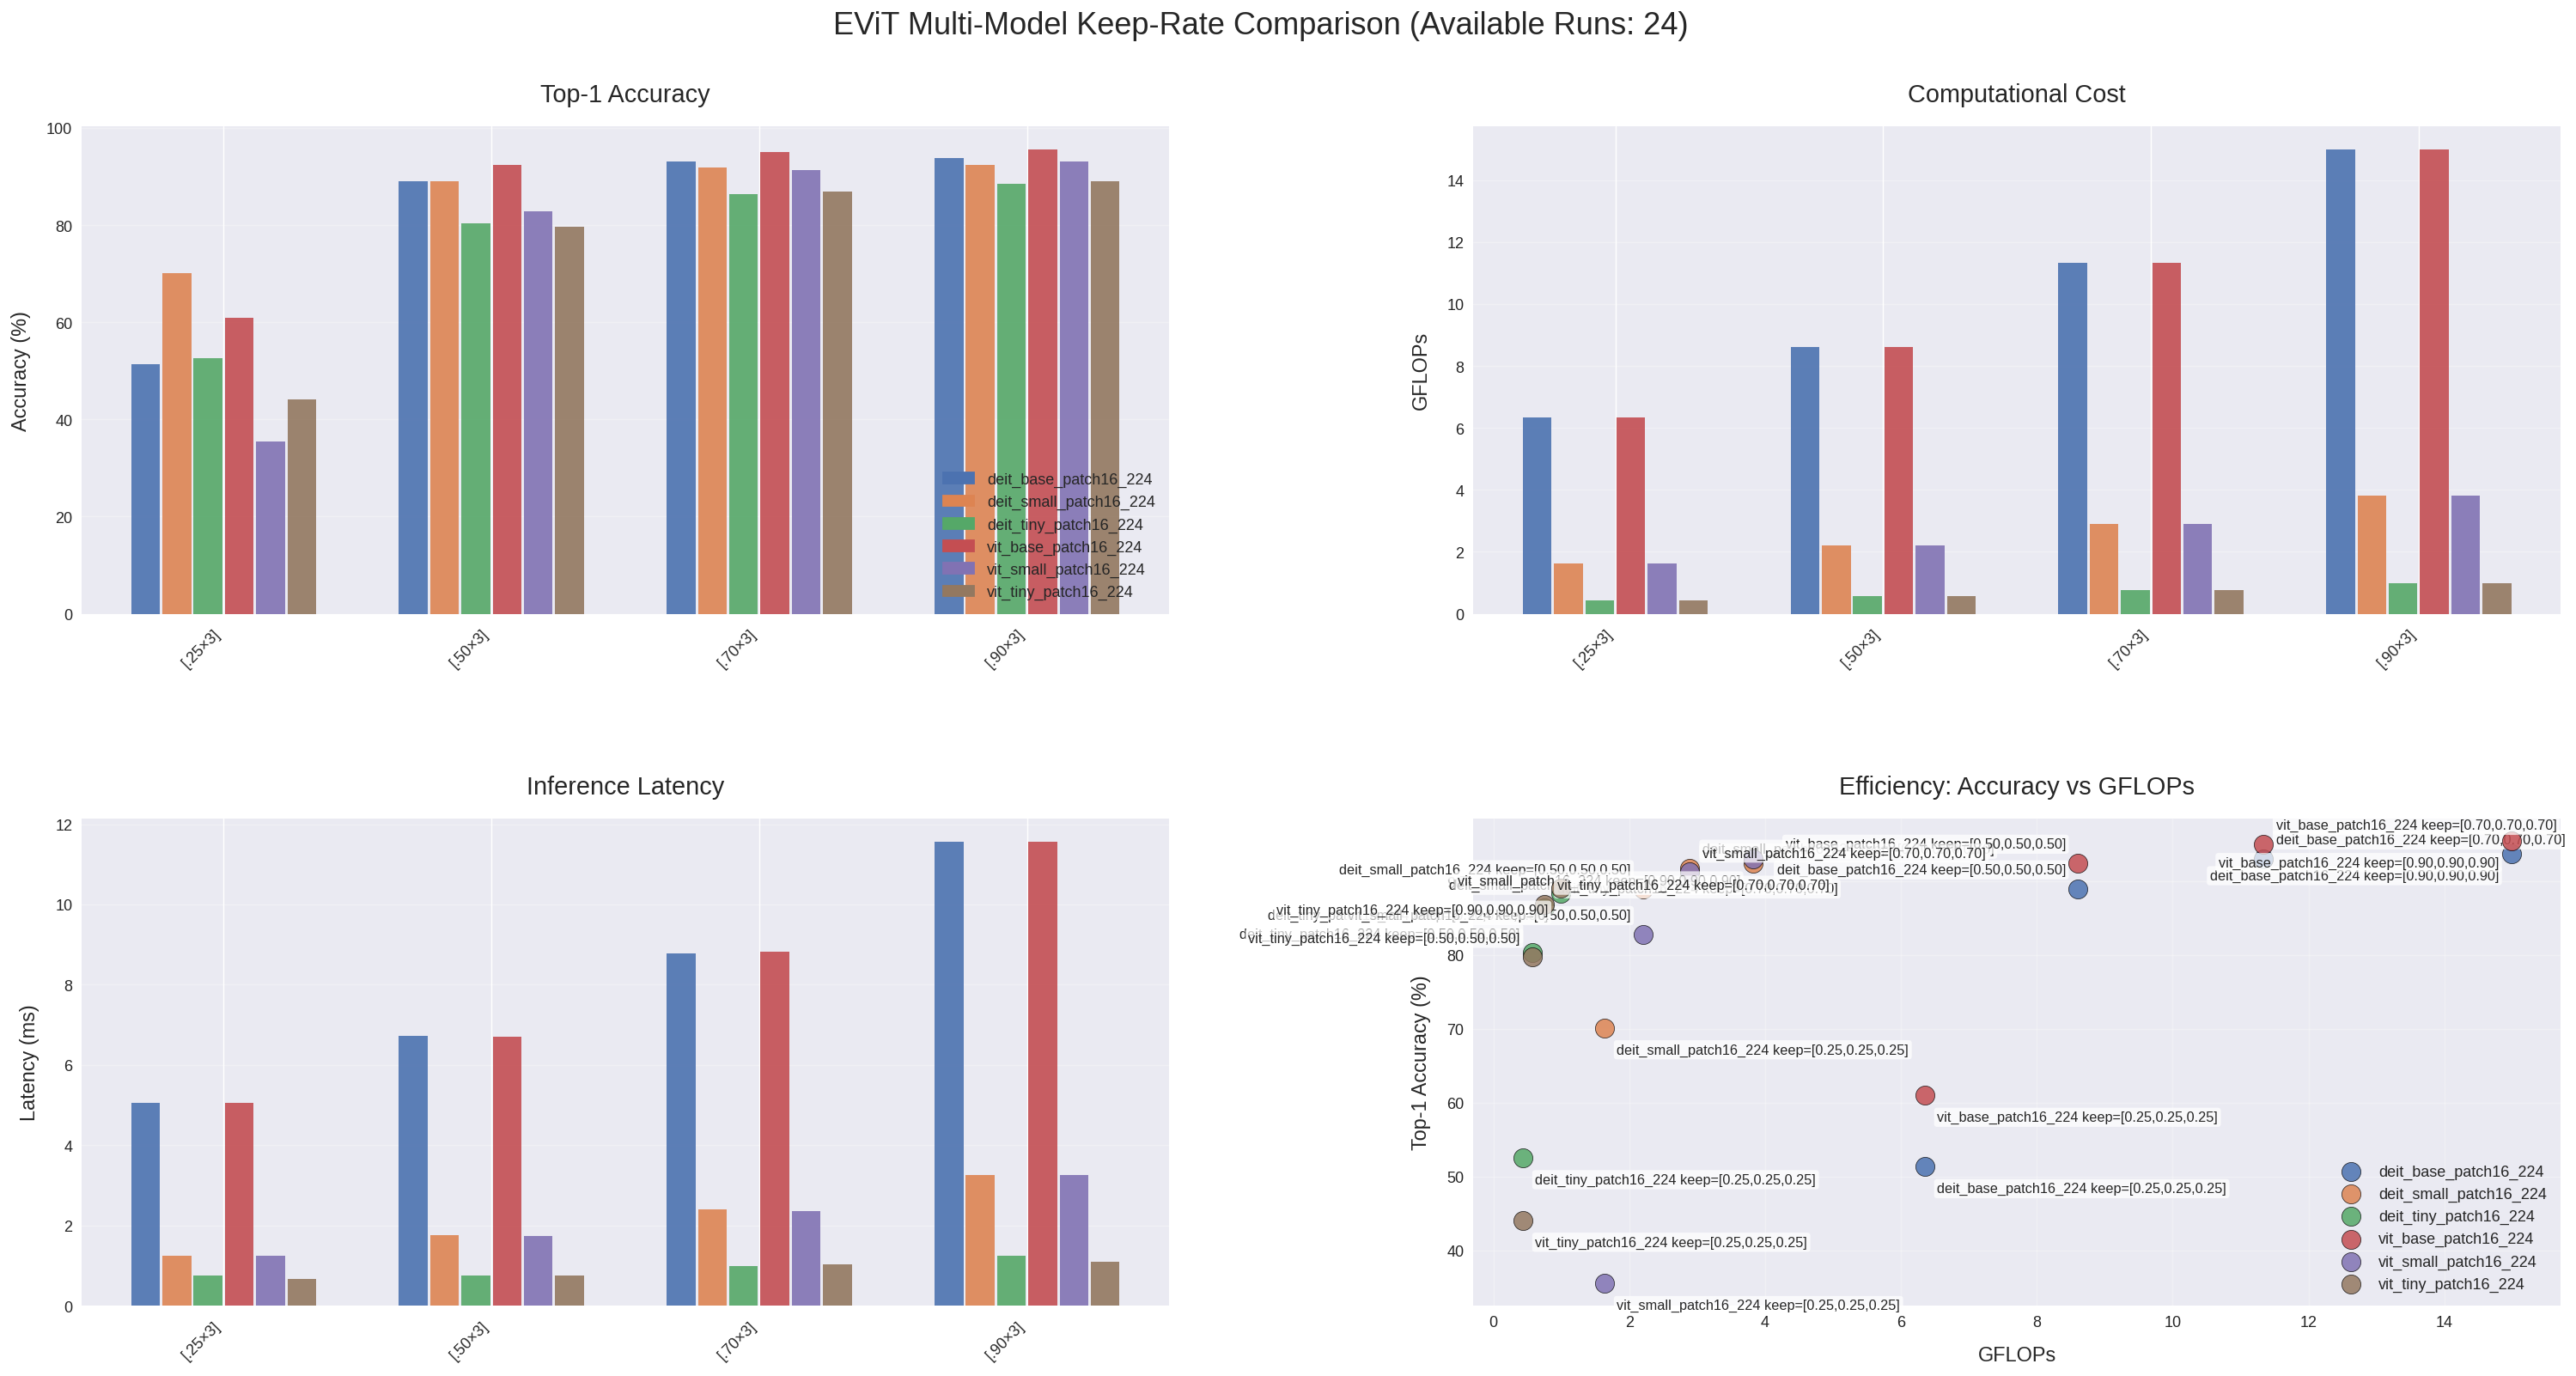


EViT Multi-Model Keep-Rate Comparison (Available Runs: 24) – Summary Table
                                      config_name                  model  params_m    gflops  acc1  latency_ms  throughput               model_id  keep_rate
 EViT deit_tiny_patch16_224 keep=[0.25,0.25,0.25]  deit_tiny_patch16_224  5.543716  0.431802 52.54    0.747353 1338.056483  deit_tiny_patch16_224       0.25
 EViT deit_tiny_patch16_224 keep=[0.50,0.50,0.50]  deit_tiny_patch16_224  5.543716  0.576300 80.34    0.751450 1330.760311  deit_tiny_patch16_224       0.50
 EViT deit_tiny_patch16_224 keep=[0.70,0.70,0.70]  deit_tiny_patch16_224  5.543716  0.752239 86.42    0.983857 1016.407659  deit_tiny_patch16_224       0.70
 EViT deit_tiny_patch16_224 keep=[0.90,0.90,0.90]  deit_tiny_patch16_224  5.543716  0.989422 88.44    1.241106  805.732823  deit_tiny_patch16_224       0.90
EViT deit_small_patch16_224 keep=[0.25,0.25,0.25] deit_small_patch16_224 21.704164  1.633914 70.16    1.253400  797.829698 deit_small_patch

In [39]:
# Final EViT visualization call (works with any subset of models/keep-rates already run)
if 'results' not in globals() or not results:
    print('No results found. Run any EViT sweep cells first.')
else:
    df_all = pd.DataFrame(results).copy()
    df_evit = df_all[df_all['config_name'].astype(str).str.startswith('EViT ')].copy()

    if df_evit.empty:
        print('No EViT results found yet.')
    else:
        extracted = df_evit['config_name'].str.extract(
            r'^EViT\s+(?P<parsed_model>\S+)\s+keep=\[(?P<keep_rate>\d+\.\d+),'
        )
        df_evit['model_id'] = df_evit.get('model', extracted['parsed_model'])
        df_evit['model_id'] = df_evit['model_id'].fillna(extracted['parsed_model'])
        df_evit['keep_rate'] = pd.to_numeric(extracted['keep_rate'], errors='coerce')

        for col in ['acc1', 'gflops', 'latency_ms', 'throughput', 'params_m']:
            if col in df_evit.columns:
                df_evit[col] = pd.to_numeric(df_evit[col], errors='coerce')

        plot_df = df_evit.dropna(subset=['acc1', 'gflops', 'latency_ms']).copy()
        if plot_df.empty:
            print('No numeric EViT results available to plot yet.')
        else:
            compare_evit_configurations_spacious(
                plot_df.to_dict(orient='records'),
                title=f'EViT Multi-Model Keep-Rate Comparison (Available Runs: {len(plot_df)})'
            )